In [1]:
from field import Field
from plotting import plot_radial_leaf_progression

In [2]:
field = Field("EDA/testfield.json")

c:\Users\gmandl\Documents\GitHub\bachelor-thesis\field.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrixA[segment["gantryAngle"]] = segment["leafSetA"]
c:\Users\gmandl\Documents\GitHub\bachelor-thesis\field.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrixB[segment["gantryAngle"]] = segment["leafSetB"]
c:\Users\gmandl\Documents\GitHub\bachelor-thesis\field.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  C

In [3]:
def degrees_to_radians(degrees_list): # written by chatgpt
    import math
    radians_list = [math.radians(angle) for angle in degrees_list]
    return radians_list

In [4]:
def plot_radial_leaf_progression(leaf_number, control_points):
    

    gantrys = []
    leafA_values = []
    leafB_values = []

    for i in control_points:
        gantrys.append(i["gantryAngle"])
        leafA_values.append(i["leafSetA"][leaf_number])
        leafB_values.append(i["leafSetB"][leaf_number])

    gantrys = degrees_to_radians(gantrys)

    offset = np.pi / 2

    fig, ax = plt.subplots(figsize = (20,10), subplot_kw={"projection":"polar"})

    ax.set_theta_offset(offset)

    ax.set_ylim(-10, 10)

    ax.set_frame_on(False)

    ax.plot(gantrys, pd.Series(leafA_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "blue")
    ax.plot(gantrys, -pd.Series(leafB_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "red")

    plt.show()

    return

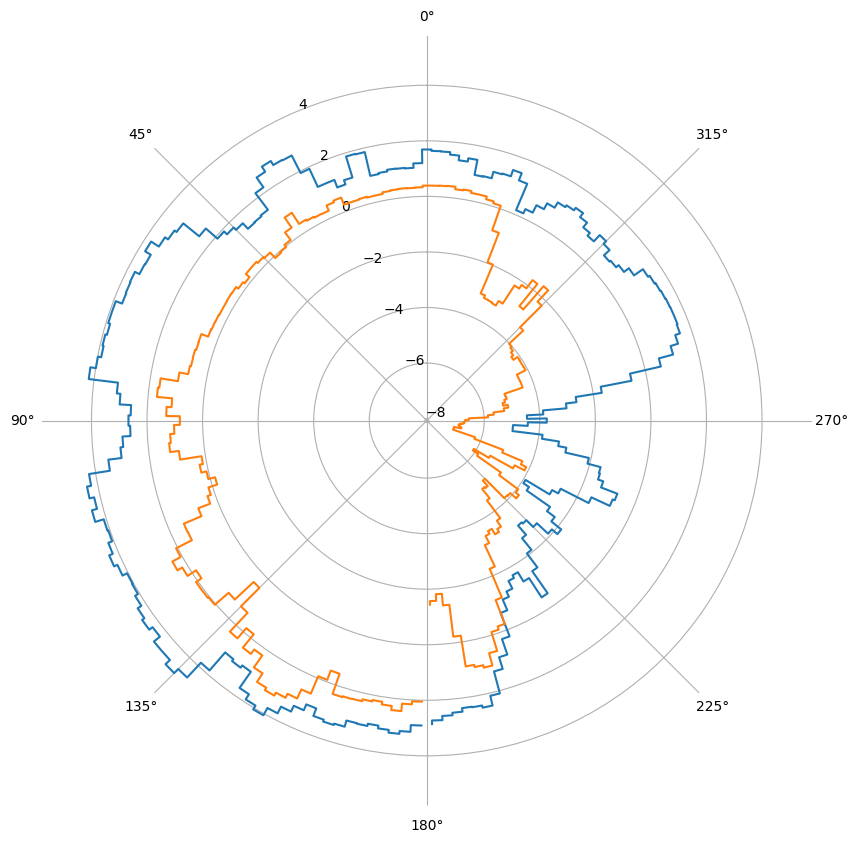

In [7]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
leaf_number = 31

leafA_values = field.matrixA.loc[leaf_number]
leafB_values = field.matrixB.loc[leaf_number]

gantrys = field.matrixA.columns

gantrys = degrees_to_radians(gantrys)
offset = np.pi / 2

fig, ax = plt.subplots(figsize = (20,10), subplot_kw={"projection":"polar"})

ax.set_theta_offset(offset)

maximum  = max(leafA_values.max(),(leafB_values*-1).max())
minimum  = min(leafA_values.min(),(leafB_values*-1).min())

ax.set_ylim(minimum-1, maximum + 1)

ax.set_frame_on(False)

ax.plot(gantrys, pd.Series(leafA_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "blue")
ax.plot(gantrys, -pd.Series(leafB_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "red")
# ax.plot(gantrys, pd.Series([(-leafB_values).median()]*180))
# ax.plot(gantrys, pd.Series([leafA_values.median()]*180))

plt.show()




In [17]:
pd.Series([(-leafB_values).mean()]*180)

0     -1.172444
1     -1.172444
2     -1.172444
3     -1.172444
4     -1.172444
         ...   
175   -1.172444
176   -1.172444
177   -1.172444
178   -1.172444
179   -1.172444
Length: 180, dtype: float64

In [29]:
import pandas as pd
leaf = 31

devs = []

radA = field.matrixA.loc[leaf].mean()
radB = field.matrixB.loc[leaf].mean()

for i in field.matrixA.columns:
    devA = abs(field.matrixA.loc[leaf,i] - radA)
    devB = abs(field.matrixB.loc[leaf,i] - radB)
    devs.append(devA * devB)

devs = pd.Series(devs, index = field.matrixA.columns)

total_leaf_dev = devs.sum()


In [24]:
radA = field.matrixA.T.mean()
radB = field.matrixB.T.mean()

devA = abs(field.matrixA.T - radA)
devB = abs(field.matrixB.T - radB)

devAB = devA*devB

leaf_rad_deviation = devAB.sum()
aperature_rad_deviation = devAB.T.sum()

field_dev = leaf_rad_deviation.sum()

In [48]:
def calculate_rad_dev(radiusA, radiusB, leaf):
    from numpy import sqrt
    devs = []

    for i in field.matrixA.columns:
        devA = abs(field.matrixA.loc[leaf,i] - radiusA)
        devB = abs(field.matrixB.loc[leaf,i] - radiusB)
        devs.append((devA * devB * field.length_matrix))

    devs = pd.Series(devs, index = field.matrixA.columns)

    total_leaf_dev = sqrt(devs.sum())

    return total_leaf_dev

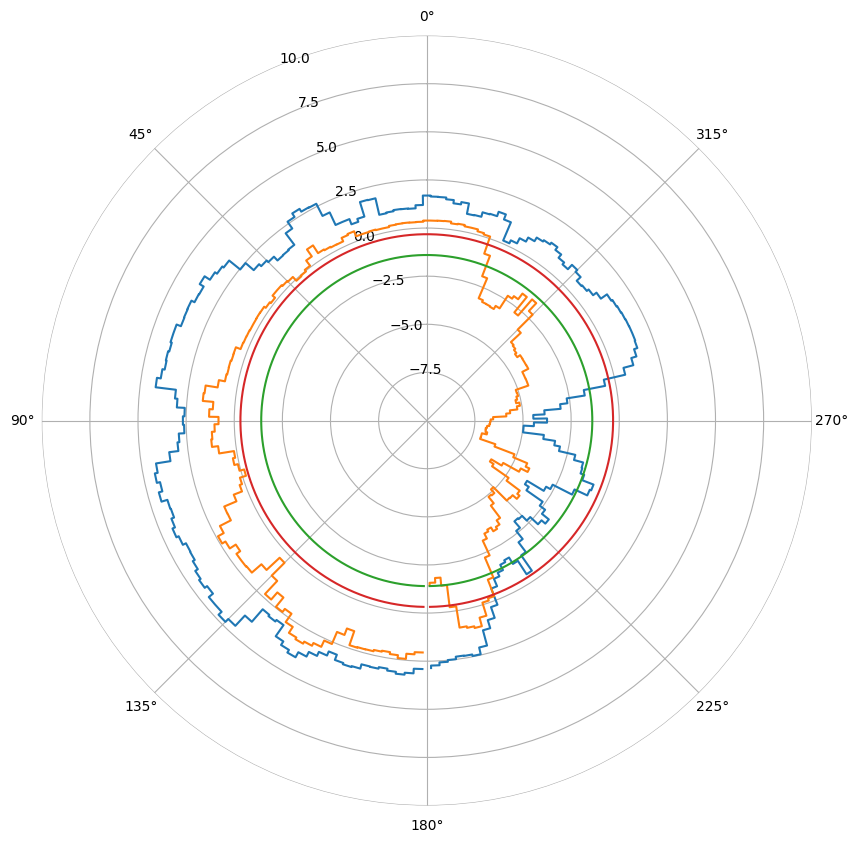

In [57]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
leaf_number = 31

leafA_values = field.matrixA.loc[leaf_number]
leafB_values = field.matrixB.loc[leaf_number]

gantrys = field.matrixA.columns

gantrys = degrees_to_radians(gantrys)
offset = np.pi / 2

fig, ax = plt.subplots(figsize = (20,10), subplot_kw={"projection":"polar"})

ax.set_theta_offset(offset)

ax.set_ylim(-10, 10)

ax.set_frame_on(False)

ax.plot(gantrys, pd.Series(leafA_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "blue")
ax.plot(gantrys, -pd.Series(leafB_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "red")
ax.plot(gantrys, pd.Series([minA]*180))
ax.plot(gantrys, pd.Series([minB]*180))

plt.show()


In [51]:
leaf = 31
minA = field.matrixA.T.loc[leaf].min()
maxA = field.matrixA.T.loc[leaf].max()
avgA = field.matrixA.T.loc[leaf].mean()

import numpy as np

rA = np.arange(minA, maxA, (maxA-minA)/10)
rA[-1] = avgA

minB = field.matrixB.T.loc[leaf].min()
maxB = field.matrixB.T.loc[leaf].max()
avgB = field.matrixB.T.loc[leaf].mean()

rB = np.arange(min, max, (max-min)/10)
rB[-1] = avgB

rad_dev_list = []
for i in range(len(rA)):

    rad_dev = calculate_rad_dev(rA[i], rB[i], leaf)
    rad_dev_list.append(rad_dev.sum())


pd.DataFrame({"radial_deviation_score":rad_dev_list})



,radial_deviation_score
0,242640.505422
1,255694.506851
2,266510.412859
3,270745.024427
4,268707.809193
5,260497.536202
6,250029.550080
7,240814.021192
8,233863.902328
9,252563.744246
